In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'
sns.set_style("ticks")

In [35]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/mousebrain.pkl' # remember to change this
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)
cluster_edges

[('Isocortex L6', 'Isocortex L5'),
 ('Isocortex L5', 'Isocortex L4'),
 ('Isocortex L4', 'Isocortex L2/3'),
 ('Isocortex L2/3', 'HIP & CTXpl L1')]

In [43]:
import pickle as pkl

clusters_path = '../clusters/mousebrain.pkl' # remember to change this
with open(clusters_path, 'rb') as f:
    clusters = pkl.load(f)
clusters

['Isocortex L6',
 'Isocortex L5',
 'Isocortex L4',
 'Isocortex L2/3',
 'HIP & CTXpl L1']

In [36]:
data = 'mousebrain_revised'
basis = 'spatial'
metric_name = 'cbdir'
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'topovelo', 'stt']
results = {}
for cluster_edge in cluster_edges: 
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {}
    for model in models:
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        # metric_file = f'../logs/{data}/{model}/{metric_name}_{basis}_{model_name}_velocity.pkl'
        metric_file = f'../logs/{model}/real/{data}/{metric_name}_{basis}_{model_name}_velocity.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        if edge in metric.keys():
            result[model] = metric[edge]
        if model == 'stt':
            # stt_metric_file = f'../logs/{data}/{model}/{metric_name}_{basis}_vj.pkl'
            stt_metric_file = f'../logs/{model}/real/{data}/{metric_name}_{basis}_vj.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            if edge in stt_metric.keys():
                result['stt_vj'] = stt_metric[edge]
    results[edge] = result
results

{'Isocortex L6 -> Isocortex L5': {'scvelo': [-0.7304509571503,
   0.4871539056562809,
   0.24635186452537206,
   -0.9406438792475567,
   0.058823193355150405,
   0.9725046241871332,
   0.8971973000668803,
   0.9973271166032491,
   0.05003732278583229,
   -0.5307949589705734,
   -0.5251832884232036,
   -0.5658911315401874,
   0.3374858064492532,
   0.2632683016858463,
   0.3809752300161196,
   0.12576801556238282,
   0.11818617843320799,
   0.14868850566184177,
   -0.41529022745529587,
   0.6862130320076281,
   -0.24487383512724653,
   -0.24662446092385748,
   0.5672953434486097,
   0.5292661448948879,
   -0.36200586396584855,
   -0.07324284938171671,
   -0.7707342427890728,
   -0.3066364523926602,
   0.5666625073735145,
   -0.7387816580042776,
   -0.1171208055476826,
   -0.5055123141424664,
   -0.6475615120908315,
   0.21968356071512857,
   -0.17499877633344418,
   -0.18609857021800857,
   -0.09933415961078476,
   -0.5697096160366202,
   0.6436438310616858,
   -0.0661727148645781,
   0

In [44]:
data = 'mousebrain_revised'
basis = 'spatial'
metric_name = 'inner_cluster_coh'
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'topovelo', 'stt']
results = {}
for cluster in clusters:
    result = {}
    for model in models:
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        # metric_file = f'../logs/{data}/{model}/{metric_name}_{basis}_{model_name}_velocity.pkl'
        metric_file = f'../logs/{model}/real/{data}/{metric_name}_{basis}_{model_name}_velocity.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        result[model] = metric[cluster]
        if model == 'stt':
            # stt_metric_file = f'../logs/{data}/{model}/{metric_name}_{basis}_vj.pkl'
            stt_metric_file = f'../logs/{model}/real/{data}/{metric_name}_{basis}_vj.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            result['stt_vj'] = stt_metric[cluster]
    results[cluster] = result
results

{'Isocortex L6': {'scvelo': [0.7996065775367368,
   0.8643103247600853,
   0.8903213438006401,
   0.7424933411066145,
   0.8097923355410369,
   0.74663708313629,
   0.5531355683142517,
   0.6923165501777143,
   0.8047425739700137,
   0.8393484099802898,
   0.8331375212853765,
   0.7649114066745529,
   0.6902740983491041,
   0.5996479867203869,
   0.9032881881377668,
   0.9106146183482892,
   0.8654161575115746,
   0.793874302779793,
   0.6880717784850514,
   0.6854567600726901,
   0.8840679130129743,
   0.7271318085052916,
   0.5343879828504339,
   0.6515918328214345,
   0.8130104516972447,
   0.836484246607048,
   0.4485338679545146,
   0.5406676117123851,
   0.7885870841995012,
   0.5398543447876624,
   0.2686454653450229,
   0.7168486638403879,
   0.7950433030252619,
   0.8096235155312723,
   0.9046061236902638,
   0.8505933286258164,
   0.7431609497404476,
   0.871335811642991,
   0.9016559604793853,
   0.7587248406316417,
   0.8312645639014654,
   0.5054050365104134,
   0.82242102

In [30]:
import pickle as pkl

data = 'hsc_revised'
basis = 'umap_ori'
metric_name = 'velocity_consistency'
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'stt']
result = {}
for model in models:
    model_name = model if model != 'scvelo' else 'scvelo_dynamical'
    # metric_file = f'../logs/{data}/{model}/{metric_name}_{basis}_{model_name}_velocity.pkl'
    metric_file = f'../logs/{model}/real/{data}/{metric_name}_{basis}_{model_name}_velocity.pkl'
    with open(metric_file, 'rb') as f:
        metric = pkl.load(f)
    result[model] = metric
    if model == 'stt':
        # stt_metric_file = f'../logs/{data}/{model}/{metric_name}_{basis}_vj.pkl'
        stt_metric_file = f'../logs/{model}/real/{data}/{metric_name}_{basis}_vj.pkl'
        with open(stt_metric_file, 'rb') as f:
            stt_metric = pkl.load(f)
        result['stt_vj'] = stt_metric
result

{'scvelo': [0.8473362799577077,
  0.9363428394479452,
  0.7038497847581086,
  0.7941426286222587,
  0.9076794790645935,
  0.8778167421560806,
  0.9209221534867589,
  0.8975248117576502,
  0.6516143580467401,
  0.7107963554857649,
  0.8881021357670437,
  0.720695751274832,
  0.7326204711106544,
  0.690080015038633,
  0.7324627073683675,
  0.9024573520839181,
  0.7268297365642802,
  0.6743189390290643,
  0.540406937150171,
  0.749216721059324,
  0.7994544094511599,
  0.7534834426114491,
  0.6692812918217554,
  0.6860216460738491,
  0.768321370824062,
  0.7219885748025302,
  0.9071608275490964,
  0.7265213543387886,
  0.7529569028907883,
  0.9018388708507651,
  0.6816918535490217,
  0.8309789808626603,
  0.9344244335829348,
  0.8377529523502,
  0.9402926217717631,
  0.5941116205454714,
  0.8574845780094198,
  0.7025043934448136,
  0.7863902492158698,
  0.7887706104946063,
  0.8278854887036736,
  0.8058153315553083,
  0.8636755114627416,
  0.6903530528807966,
  0.9024765701344375,
  0.6543

In [45]:
model_colors = {
    "scvelo": "#1f77b4",
    "scvelo_avg": "#02ccfe",
    "velovae": "#d62728",
    "topovelo": "#2ca02c",
    "velovi": "#ff7f0e",
    "unitvelo": "#9467bd",
    "deepvelo_cui": "#8c564b",
    "stt": "#e377c2",
    "stt_vj": "#cd8c95"
}

In [46]:
import os
save_dir = f'../results/results_0128/{data}/metrics'
os.makedirs(save_dir, exist_ok=True)

/tmp/ipykernel_3154760/1868359226.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='model', y=metric_name, data=df, palette=model_colors)


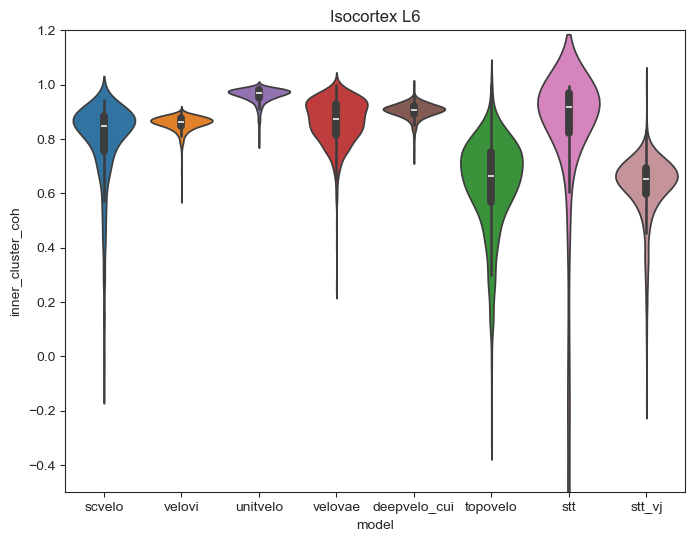

/tmp/ipykernel_3154760/1868359226.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='model', y=metric_name, data=df, palette=model_colors)


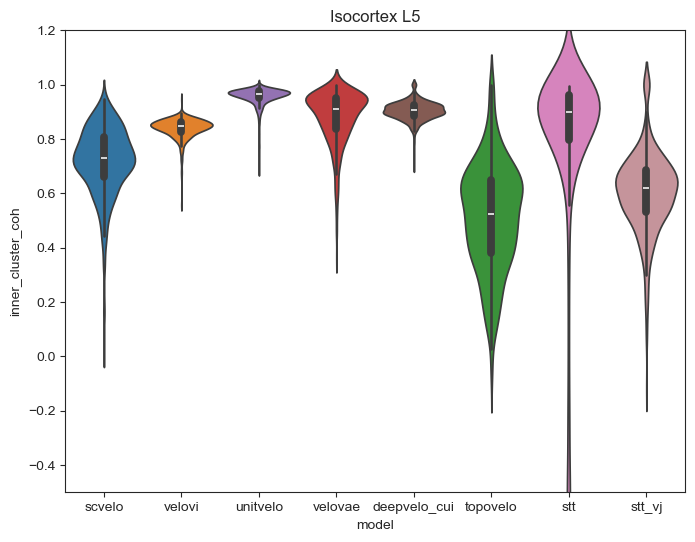

/tmp/ipykernel_3154760/1868359226.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='model', y=metric_name, data=df, palette=model_colors)


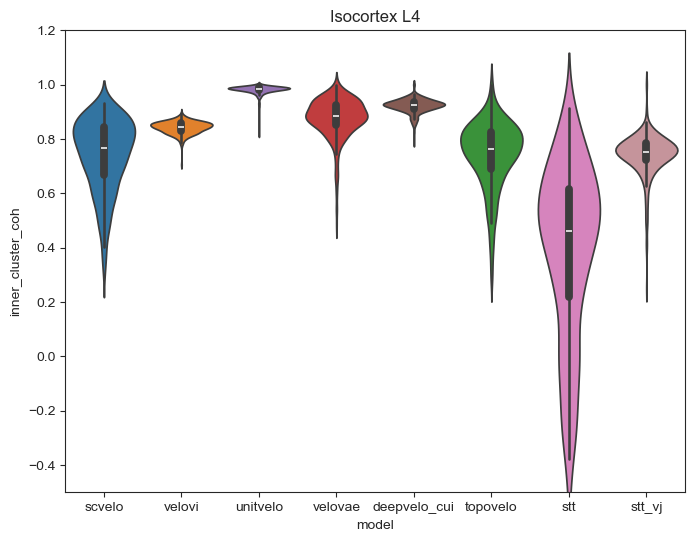

/tmp/ipykernel_3154760/1868359226.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='model', y=metric_name, data=df, palette=model_colors)


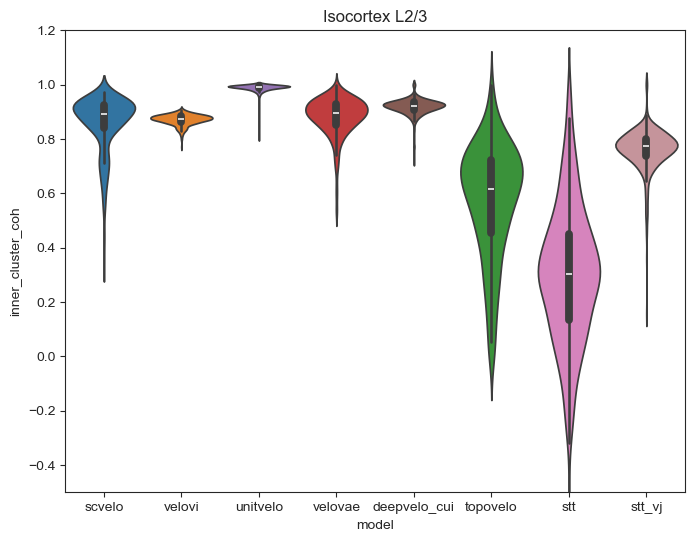

/tmp/ipykernel_3154760/1868359226.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='model', y=metric_name, data=df, palette=model_colors)


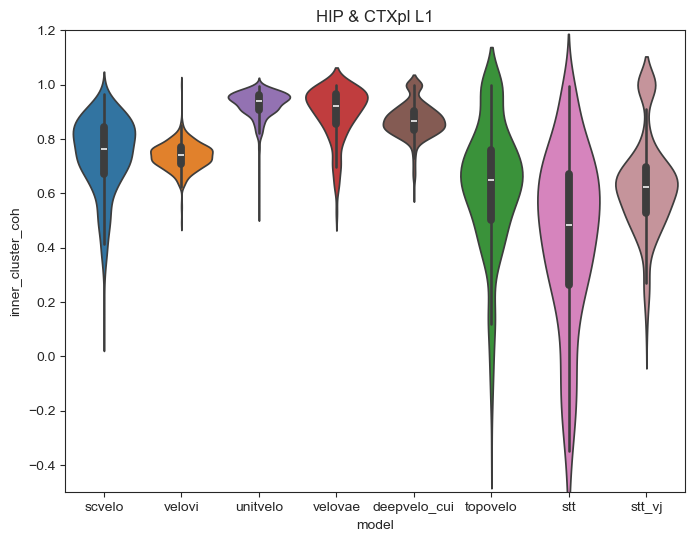

In [50]:
for key, value in results.items():
    df = pd.DataFrame([(k, v) for k, values in value.items() for v in values], columns=["model", metric_name])
    plt.figure(figsize=(8, 6))
    sns.violinplot(x='model', y=metric_name, data=df, palette=model_colors)
    plt.ylim(-0.5, 1.2) # remember to change this
    plt.title(key)
    plt.savefig(f'{save_dir}/{metric_name}_{key.replace(" -> ", "_").replace(" ", "_").replace("/", "_")}.svg')
    plt.show()

/tmp/ipykernel_3154760/2479734518.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='model', y=metric_name, data=df, palette=model_colors)


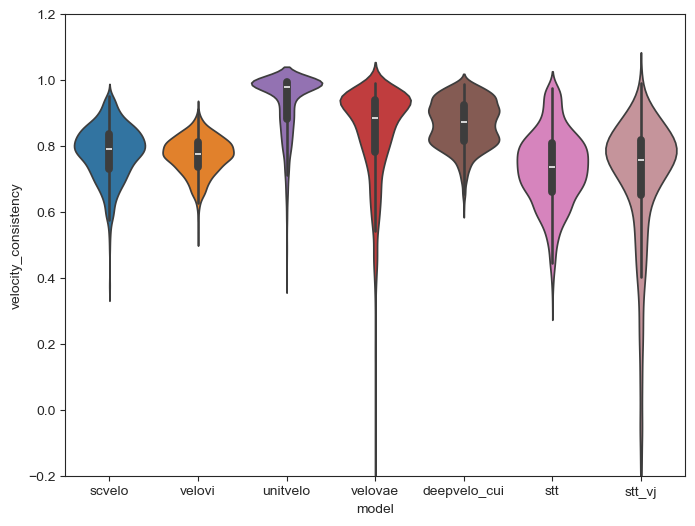

In [32]:
df = pd.DataFrame([(k, v) for k, values in result.items() for v in values], columns=["model", metric_name])
plt.figure(figsize=(8, 6))
sns.violinplot(x='model', y=metric_name, data=df, palette=model_colors)
plt.ylim(-0.2, 1.2)
plt.savefig(f'{save_dir}/{metric_name}.svg')
plt.show()